# Sales Forecasting and Analysis

## Project Information

**Project Type:** Sales Analysis and Forecasting

**Dataset:** Sample Superstore Sales Dataset

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Statsmodels, Scikit-learn, Jupyter Notebook

**Dataset Size:** 9,994 orders and 21 features

**Data Period:** January 2014 to December 2017

**Objective:** Analyze historical sales and profitability patterns and forecast future monthly sales using time-series analysis.

**Analysis Performed:**
- Data cleaning and preprocessing
- Monthly and yearly sales analysis
- Category and sub-category analysis
- Regional sales and profit analysis
- Discount and profit relationship analysis
- Moving-average analysis
- Time-series forecasting using Holt-Winters Exponential Smoothing
- Forecast evaluation using MAE and RMSE
- Historical sales and forecast visualization

**Key Metrics:**
- Total sales: 2,297,200.86
- Total profit: 286,397.02
- Total quantity sold: 37,873
- Average order sales: 229.86
- Highest monthly sales: 118,447.82
- Lowest monthly sales: 4,519.89
- Forecasted sales for the next 6 months: 363,796.18
- Forecast MAE: 7,319.85
- Forecast RMSE: 9,083.47

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("Sample_Superstore.csv", encoding="latin1")

In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [16]:
print("First Order Date:", df["Order Date"].min())
print("Last Order Date:", df["Order Date"].max())

First Order Date: 2014-01-03 00:00:00
Last Order Date: 2017-12-30 00:00:00


In [18]:
monthly_sales = df.set_index("Order Date")["Sales"].resample("ME").sum()

monthly_sales.head()

Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

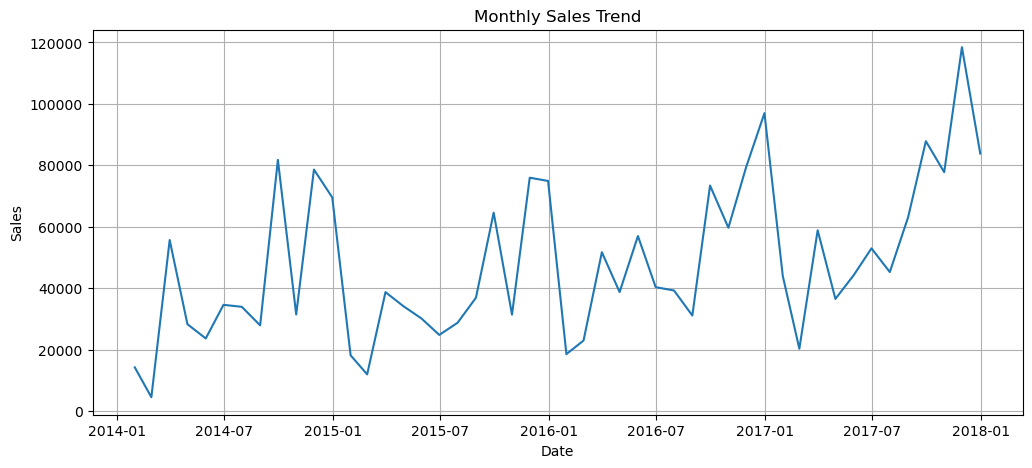

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [22]:
yearly_sales = df.set_index("Order Date")["Sales"].resample("YE").sum()

yearly_sales

Order Date
2014-12-31    484247.4981
2015-12-31    470532.5090
2016-12-31    609205.5980
2017-12-31    733215.2552
Freq: YE-DEC, Name: Sales, dtype: float64

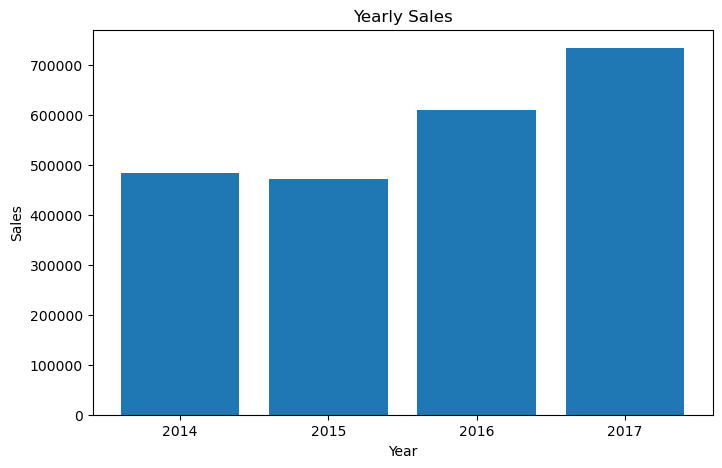

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(yearly_sales.index.year, yearly_sales.values)

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(yearly_sales.index.year)
plt.show()

In [26]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

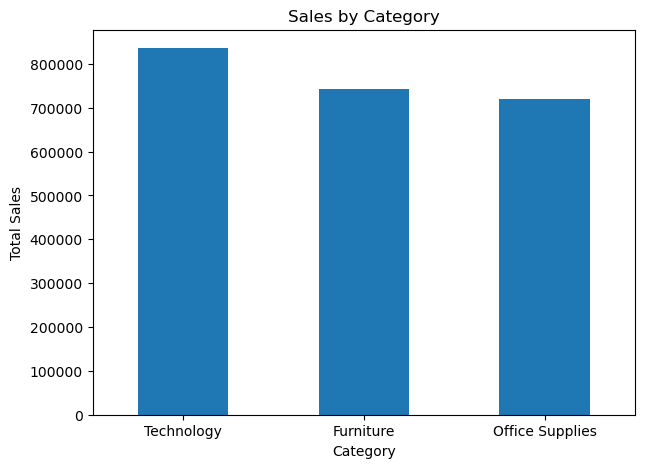

In [28]:
category_sales.plot(kind="bar", figsize=(7, 5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [30]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

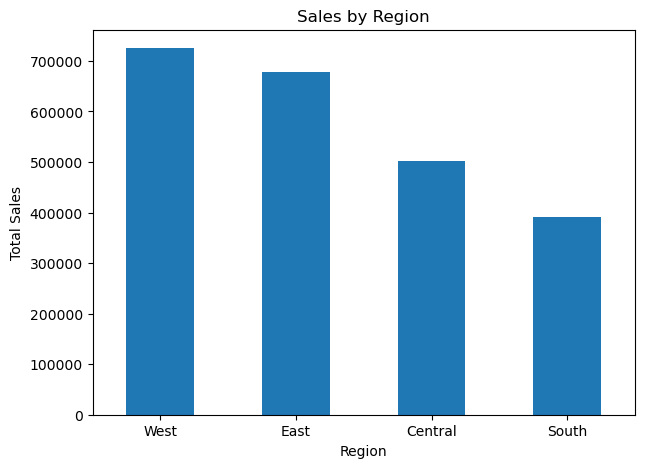

In [32]:
region_sales.plot(kind="bar", figsize=(7, 5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [34]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

subcategory_sales

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

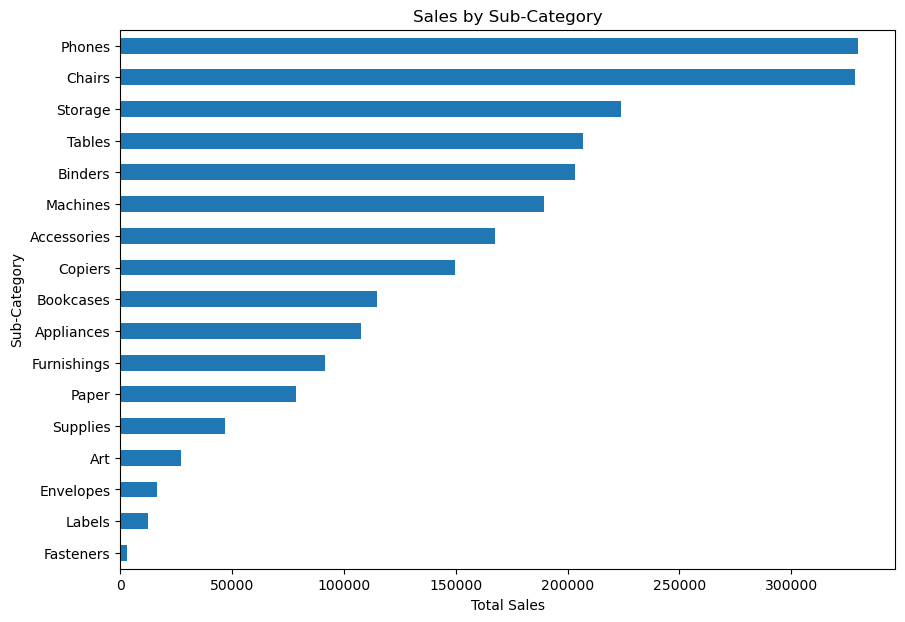

In [36]:
plt.figure(figsize=(10, 7))

subcategory_sales.sort_values().plot(kind="barh")

plt.title("Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.show()


In [38]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

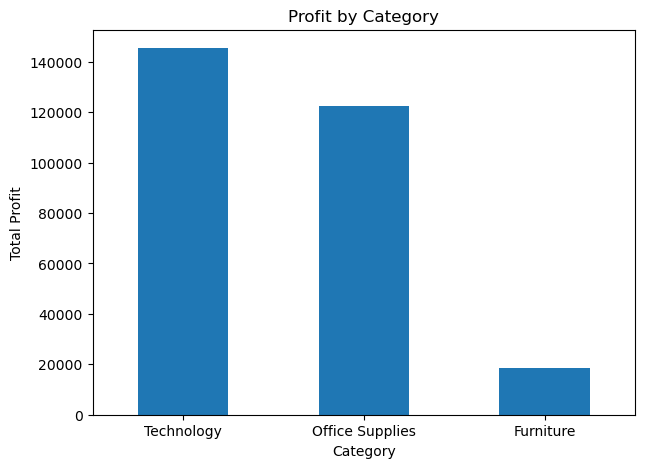

In [40]:
category_profit.plot(kind="bar", figsize=(7, 5))

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

In [42]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

region_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

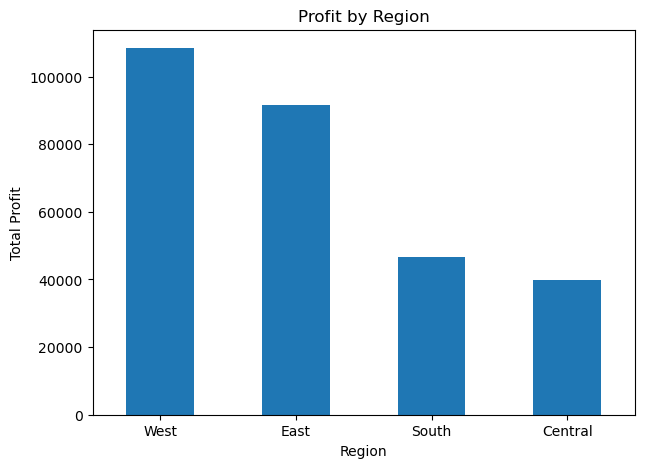

In [44]:
region_profit.plot(kind="bar", figsize=(7, 5))

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

In [46]:
discount_profit = df[["Discount", "Profit"]].corr()

discount_profit

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


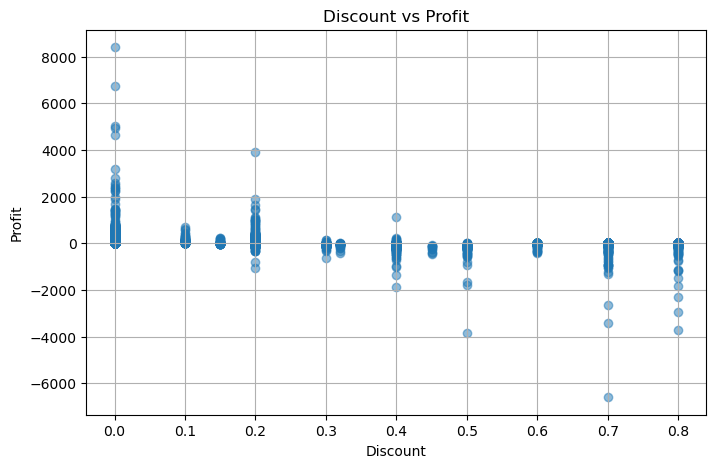

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Discount"], df["Profit"], alpha=0.5)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

In [50]:
forecast_data = monthly_sales.reset_index()

forecast_data.columns = ["Date", "Sales"]

forecast_data.head()

,Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [52]:
forecast_data["3_Month_MA"] = forecast_data["Sales"].rolling(window=3).mean()

forecast_data.tail()

,Date,Sales,3_Month_MA
43,2017-08-31,63120.8880,53789.009900
44,2017-09-30,87866.6520,65417.318667
45,2017-10-31,77776.9232,76254.821067
46,2017-11-30,118447.8250,94697.133400
47,2017-12-31,83829.3188,93351.355667


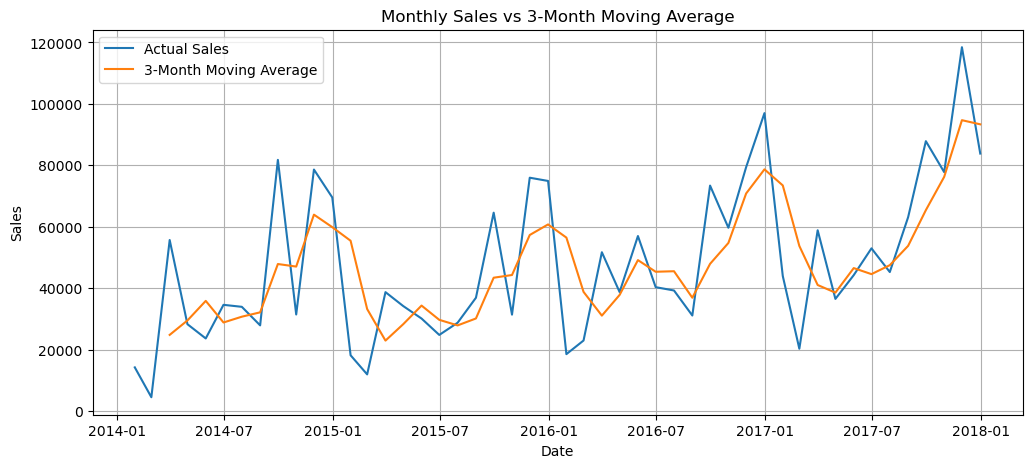

In [54]:
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_data["Date"],
    forecast_data["Sales"],
    label="Actual Sales"
)

plt.plot(
    forecast_data["Date"],
    forecast_data["3_Month_MA"],
    label="3-Month Moving Average"
)

plt.title("Monthly Sales vs 3-Month Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit = model.fit()

forecast = fit.forecast(6)

forecast

C:\Users\swarna\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


2018-01-31    50321.382449
2018-02-28    42480.259261
2018-03-31    74560.388209
2018-04-30    61838.886811
2018-05-31    69236.677656
2018-06-30    65358.588777
Freq: ME, dtype: float64

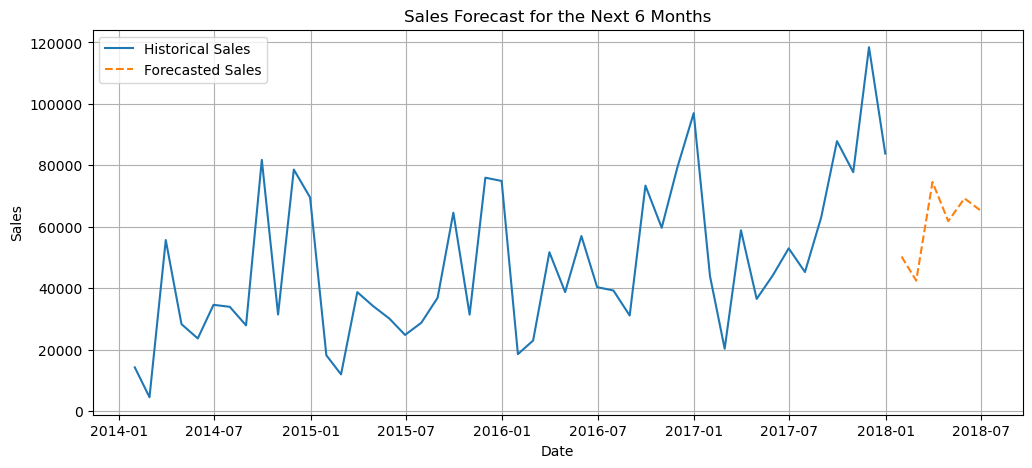

In [58]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Historical Sales"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecasted Sales",
    linestyle="--"
)

plt.title("Sales Forecast for the Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

fitted_values = fit.fittedvalues

mae = mean_absolute_error(monthly_sales, fitted_values)
rmse = np.sqrt(mean_squared_error(monthly_sales, fitted_values))

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Absolute Error (MAE): 7319.85
Root Mean Squared Error (RMSE): 9083.47


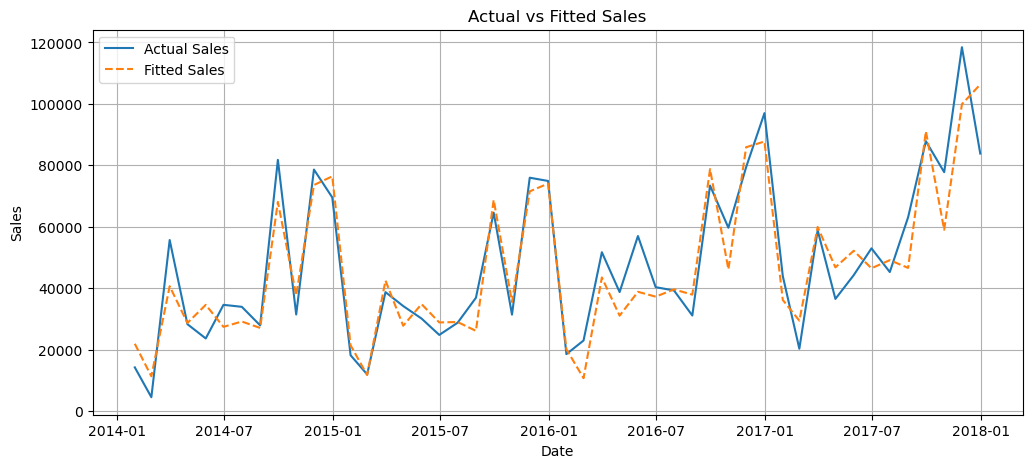

In [62]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Actual Sales"
)

plt.plot(
    monthly_sales.index,
    fitted_values,
    label="Fitted Sales",
    linestyle="--"
)

plt.title("Actual vs Fitted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Quantity Sold:", df["Quantity"].sum())
print("Average Order Sales:", round(df["Sales"].mean(), 2))
print("Highest Monthly Sales:", round(monthly_sales.max(), 2))
print("Lowest Monthly Sales:", round(monthly_sales.min(), 2))
print("Forecasted Sales - Next 6 Months:", round(forecast.sum(), 2))

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity Sold: 37873
Average Order Sales: 229.86
Highest Monthly Sales: 118447.82
Lowest Monthly Sales: 4519.89
Forecasted Sales - Next 6 Months: 363796.18


## Key Findings

- Total sales across the dataset were **2,297,200.86**, with total profit of **286,397.02**.
- Sales increased substantially from **2015 to 2017**, with 2017 recording the highest annual sales.
- **Technology** generated the highest sales among the three product categories.
- **Technology** also generated the highest total profit, while Furniture generated much lower profit relative to its sales.
- The **West region** recorded the highest total sales and highest total profit.
- **Phones** and **Chairs** were the highest-selling sub-categories by total sales.
- The correlation between **Discount and Profit was -0.219**, indicating a weak negative relationship in this dataset.
- A 3-month moving average was used to smooth short-term fluctuations in monthly sales.
- A **Holt-Winters Exponential Smoothing** model was used to forecast the next six months of sales.
- The model forecast approximately **363,796.18** in total sales for the six-month forecast period.
- The model evaluation produced an **MAE of 7,319.85** and an **RMSE of 9,083.47**.

## Conclusion

The Sales Forecasting and Analysis project provided insights into historical sales, profitability, product categories, regional performance, and discount patterns. The analysis showed that sales increased notably in the later years of the dataset, while Technology generated the highest sales and profit among the product categories.

A 3-month moving average was used to identify the underlying sales trend, followed by a Holt-Winters Exponential Smoothing model to forecast future monthly sales. The model generated a six-month forecast of approximately 363,796.18 in total sales.

This project demonstrated how Python can be used for data cleaning, exploratory data analysis, visualization, time-series analysis, and sales forecasting. It also provided practical experience in evaluating a forecasting model using MAE and RMSE.